# Labeling the Angular Character of Yb171

In multi-channel quantum defect theory (MQDT), an eigenstate is a superposition of several channels,
each of which comes with its own set of angular quantum numbers. Apart from the total momentum $F$,
its projection $M$ and the parity, the angular quantum numbers are therefore no good quantum numbers
anymore and a state can only be labeled by *expectation values*.

Since database format v2, the PairInteraction database stores for every state the expectation value
$\varnothing X = \langle X \rangle$ **and** the standard deviation
$\sigma_X = \sqrt{\langle X^2 \rangle - \langle X \rangle^2}$ of the angular quantum numbers of all
coupling schemes:

- the individual angular momenta: $l_{\mathrm{Ryd}}$, $s_{\mathrm{Ryd}}$, $l_{\mathrm{core}}$,
  $s_{\mathrm{core}}$, $i_{\mathrm{core}}$,
- LS coupling of the valence electrons: $L$, $S$, $J$,
- jj coupling of the valence electrons: $j_{\mathrm{Ryd}}$, $j_{\mathrm{core}}$,
- FJ coupling of the hyperfine structure of the ionic core: $F_{\mathrm{core}}$.

They are available from every `KetAtom` object, either via the dedicated properties (`ket.j`,
`ket.j_std`, ...) or via `ket.get_quantum_number(name)` and `ket.get_quantum_number_std(name)`. A
standard deviation of zero means that the quantum number is exact for this state.

Below we use these values to visualize how the character of the $S$-like ($l_{\mathrm{Ryd}} = 0$),
$F = 1/2$ series of Yb171 changes with the effective principal quantum number $\nu$.

In [1]:
import logging

import matplotlib.pyplot as plt
import numpy as np
import pairinteraction.real as pi

if pi.Database.get_global_database() is None:
    pi.Database.initialize_global_database(download_missing=True)

# we deliberately also look at low-lying states, for which quantum defect theory is less
# accurate, and thus silence the warning about them
logging.getLogger("pairinteraction").setLevel(logging.ERROR)

We construct a basis containing all $S$-like states with $F = 1/2$. Because $l_{\mathrm{Ryd}}$ is
only an expectation value, we restrict it to the interval $[-0.5, 0.5]$ instead of requiring it to be
exactly zero. We also use `mode="exact"`, which applies the restrictions to the expectation values
themselves; the default `mode="fuzzy"` would additionally keep all states whose expectation value is
within two standard deviations of the requested interval.

In [2]:
f = 1 / 2
basis = pi.BasisAtom(
    "Yb171_mqdt", nu=(0, 130), f=(f, f), m=(f, f), l_ryd=(-0.5, 0.5), mode="exact"
)

kets = basis.kets  # the kets are sorted by energy and thus also by nu
print(f"Number of states in the basis: {len(kets)}")
print(f"  nu_min = {kets[0].nu:.3f}, nu_max = {kets[-1].nu:.3f}")

Number of states in the basis: 159
  nu_min = 2.501, nu_max = 79.725


For each of these states the database provides the expectation values and standard deviations of the
angular quantum numbers:

In [3]:
qns = ["l_ryd", "s", "j", "j_core", "f_core"]

print("     nu  " + "".join(f"{qn:>16s}" for qn in qns))
for ket in kets[::20]:
    exp_std = [(ket.get_quantum_number(qn), ket.get_quantum_number_std(qn)) for qn in qns]
    print(f"{ket.nu:7.2f}  " + "".join(f"{e:8.2f} ± {s:<5.2f}" for e, s in exp_std))

     nu             l_ryd               s               j          j_core          f_core
   2.50      0.00 ± 0.00     1.00 ± 0.00     1.00 ± 0.00     0.50 ± 0.00     0.25 ± 0.43 
  11.76      0.01 ± 0.12     0.00 ± 0.02     0.00 ± 0.01     0.51 ± 0.10     0.76 ± 0.44 
  21.55      0.00 ± 0.00     1.00 ± 0.04     1.00 ± 0.04     0.50 ± 0.00     0.21 ± 0.41 
  31.51      0.00 ± 0.00     0.98 ± 0.13     0.98 ± 0.13     0.50 ± 0.00     0.15 ± 0.36 
  41.45      0.00 ± 0.00     0.95 ± 0.22     0.95 ± 0.22     0.50 ± 0.00     0.09 ± 0.29 
  51.33      0.00 ± 0.00     0.90 ± 0.30     0.90 ± 0.30     0.50 ± 0.00     0.06 ± 0.23 
  61.16      0.00 ± 0.00     0.86 ± 0.35     0.86 ± 0.35     0.50 ± 0.00     0.05 ± 0.21 
  70.92      0.00 ± 0.00     0.80 ± 0.40     0.80 ± 0.40     0.50 ± 0.00     0.09 ± 0.29 


Plotting $\varnothing J$ and $\varnothing F_{\mathrm{core}}$ (the shaded areas indicate one standard
deviation) nicely shows the transition between the two coupling schemes: for small $\nu$ the
Rydberg electron is still strongly coupled to the core, so $J$ is a nearly exact quantum number
($J = 0$ and $J = 1$ with vanishing standard deviation) while $F_{\mathrm{core}}$ is strongly mixed.
For large $\nu$ the Rydberg electron decouples from the core, the hyperfine structure of the ionic
core is resolved and $F_{\mathrm{core}} \in \{0, 1\}$ becomes the good quantum number instead.

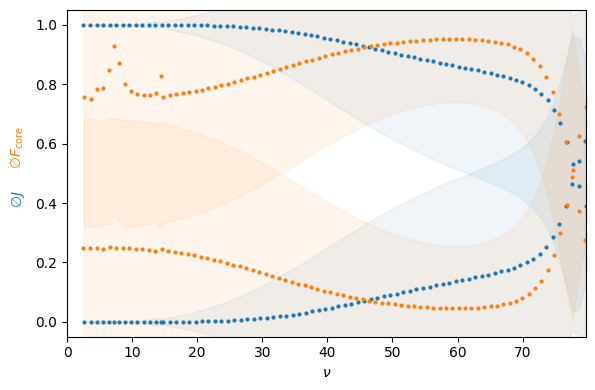

In [4]:
fig, ax = plt.subplots(figsize=(6, 4))

qns_of_interest = ["j", "f_core"]
labels = {
    "s": r"S",
    "l": r"L",
    "j": r"J",
    "j_ryd": r"j_{\mathrm{Ryd}}",
    "j_core": r"j_{\mathrm{core}}",
    "f_core": r"F_{\mathrm{core}}",
    "i_core": r"I",
}

nu = np.array([ket.nu for ket in kets])
for i, qn in enumerate(qns_of_interest):
    exp = np.array([ket.get_quantum_number(qn) for ket in kets])
    std = np.array([ket.get_quantum_number_std(qn) for ket in kets])

    # the series consists of two branches, which we plot separately to not connect them
    mean = np.mean(exp)
    for branch in [exp < mean, exp >= mean]:
        ax.plot(nu[branch], exp[branch], f"C{i}o", ms=2)
        ax.fill_between(
            nu[branch],
            exp[branch] - std[branch],
            exp[branch] + std[branch],
            color=f"C{i}",
            alpha=0.07,
        )

ax.set_xlabel(r"$\nu$")
for i, qn in enumerate(qns_of_interest):
    label = rf"$\varnothing {labels[qn]}$"
    ax.text(
        -0.11,
        0.5 + (2 * i - 1) * 0.08,
        label,
        transform=ax.transAxes,
        rotation=90,
        va="center",
        color=f"C{i}",
    )

ax.set_xlim(0, nu[-1])
ax.set_ylim(-0.05, 1.05)

fig.tight_layout()
plt.show()

## Which coupling scheme labels a state best?

Instead of looking at the quantum numbers one by one, `ket.get_coupling_scheme_std` combines the
standard deviations of all quantum numbers that are specific to one coupling scheme into a single
number $\sigma = \sqrt{\sum_X \sigma_X^2}$:

- `"LS"`: $S$, $L$, $J$,
- `"JJ"`: $j_{\mathrm{core}}$, $j_{\mathrm{Ryd}}$, $J$,
- `"FJ"`: $j_{\mathrm{core}}$, $F_{\mathrm{core}}$, $j_{\mathrm{Ryd}}$.

The smaller this value, the better the state is described by the corresponding coupling scheme, and a
value of zero means that all its quantum numbers are exact. Comparing the three values therefore
tells which coupling scheme labels a state best. For the $S$-like series of Yb171 the crossover
happens at $\nu \approx 45$: below it the Rydberg electron is still coupled to the core, so LS and
JJ coupling describe the states well, above it the hyperfine structure of the ionic core is resolved
and FJ coupling takes over.

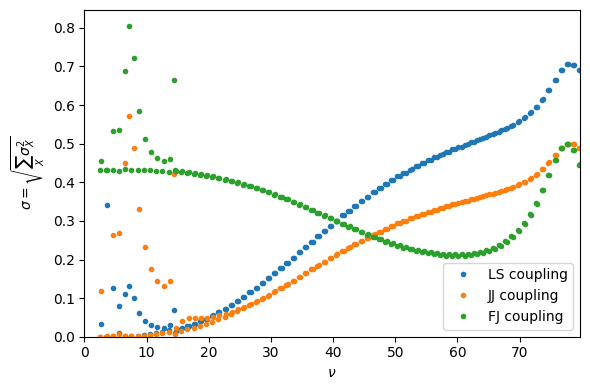

In [5]:
fig, ax = plt.subplots(figsize=(6, 4))

coupling_schemes = ["LS", "JJ", "FJ"]
for i, coupling_scheme in enumerate(coupling_schemes):
    std = np.array([ket.get_coupling_scheme_std(coupling_scheme) for ket in kets])
    ax.plot(nu, std, f"C{i}o", ms=3, label=f"{coupling_scheme} coupling")

ax.set_xlabel(r"$\nu$")
ax.set_ylabel(r"$\sigma = \sqrt{\sum_X \sigma_X^2}$")
ax.legend()

ax.set_xlim(0, nu[-1])
ax.set_ylim(bottom=0)

fig.tight_layout()
plt.show()